# Fractional Brownian Motion Parameter Estimation Using Variance Aggregation

Consider a time series of $n$, identically distributed samples,</br>

$
\begin{align}
X_1, X_2,X_3,\ldots,X_n
\end{align}
\tag{1}
$

Divide the series into $d$ smaller series of length $m$ where $md=n$.\ and let, $k = 0,1,2,3,\ldots,d-1$ and define the aggregated sum by,

$
\begin{align}
X_k^m &= \frac{1}{m}\left( X_{km+1} + X_{km+2} + \cdots + X_{km+m-1} + X_{km+m} \right) \\
&= \frac{1}{m} \left( X_{km+1} + \cdots + X_{(k+1)m} \right) \\
&= \frac{1}{m} \sum_{i=km+1}^{(k+1)m} X_i
\end{align}
\tag{2}
$

The aggregated mean is given by,

$
\begin{align}
\text{E}[X^m] &= \frac{1}{d}\sum_{i=1}^d X_i^m \\
&= \frac{1}{dm} \sum_{i=1}^d \sum_{j=im+1}^{(k+1)i} X_j \\
&= \frac{1}{n} \sum_{i=1}^n X_i
\end{align}
\tag{3}
$

and the aggregated variance by,

$
\begin{align}
\text{Var}[X^m] = \frac{1}{d} \sum_{i=1}^d\left( X^m_i - \text{E}[X^m] \right)^2
\end{align}
\tag{4}
$

This method makes use of the self similarity of fractional brownian motion. Consider the aggregated process,

$
\begin{align}
X_0^m = \frac{1}{m} \sum_{i=1}^m X_i
\end{align}
\tag{5}
$

From self similarity of fractional brownian motion,

$
\begin{align}
X_{ai} \sim a^H X_i
\end{align}
\tag{6}
$

Since the distribution of the sum of Gaussian random variables is the distribution of the last it follows that,</br> 

$
\begin{align}
X_0^m \sim \frac{1}{m} X_m \sim \frac{m^H}{m} X_1 = m^{H-1} X_1
\end{align}
\tag{7}
$

For fractional brownian noise,

$
\begin{align}
&\text{E}[\Delta Z^H_t] = 0 \\
&\text{Var}[\Delta Z^H_t] = \Delta t^{2H}
\end{align}
\tag{8}
$

$X_1$ is a single increment of brownian motion it follows that,

$
\begin{align}
\text{Var}[X_1] = \Delta t^{2H} = \sigma^2
\end{align}
\tag{9}
$

so,

$
\begin{align}
\text{Var}[X_0^m] = \text{Var}[m^{H-1} X_1] = m^{2(H-1)}\text{Var}[X_1] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{10}
$

From stationarity of it follows that,

$
\begin{align}
\text{Var}[X_k^m] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{11}
$

It follows that $H$ can be determined by using OLS on $\text{Var}[X_k^m]$ as a function of $m$.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import variance_agg, stack, curve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
Δt = 1.0
npts = 2**10
nagg = 100

def var_agg_comparison(t, fbm_noise, H):
    m_vals = [1, 10, 50]
    title = f"Aggregated Fractional Brownian Noise: Δt={Δt}, H={H}"
    labels = [f"m={m}" for m in m_vals]
    params = [{"m": m} for m in m_vals]
    func = lambda **kwargs: stats.compute_agg(t, fbm_noise, **kwargs)
    t_scan, m_scan = create_parameter_scan(func, *params)
    ylabels = [r"$X^1$", r"$X^{10}$", r"$X^{50}$"]
    stack(m_scan, t_scan, ylim=(-3.5, 3.5), ylabels=ylabels, xlabel=r"$t$", title=title, labels=labels)

## Simulation $H=0.8$

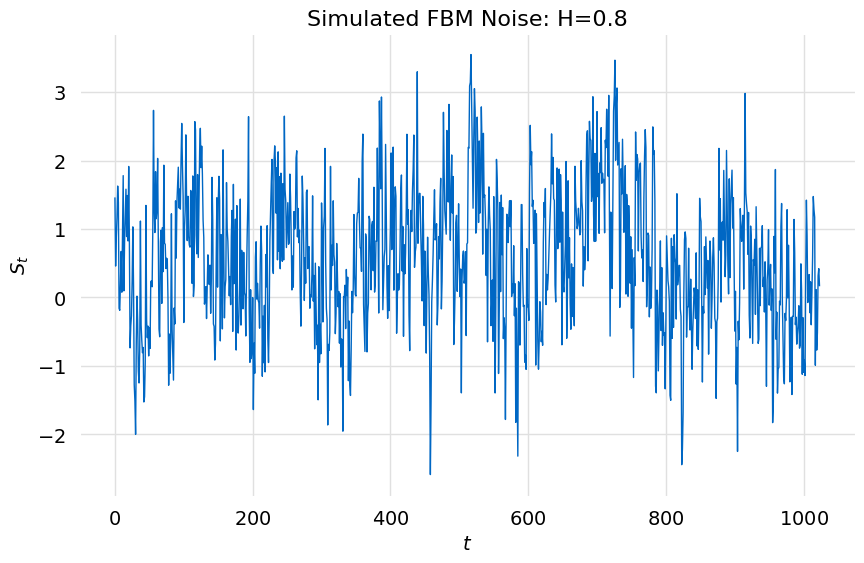

In [3]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

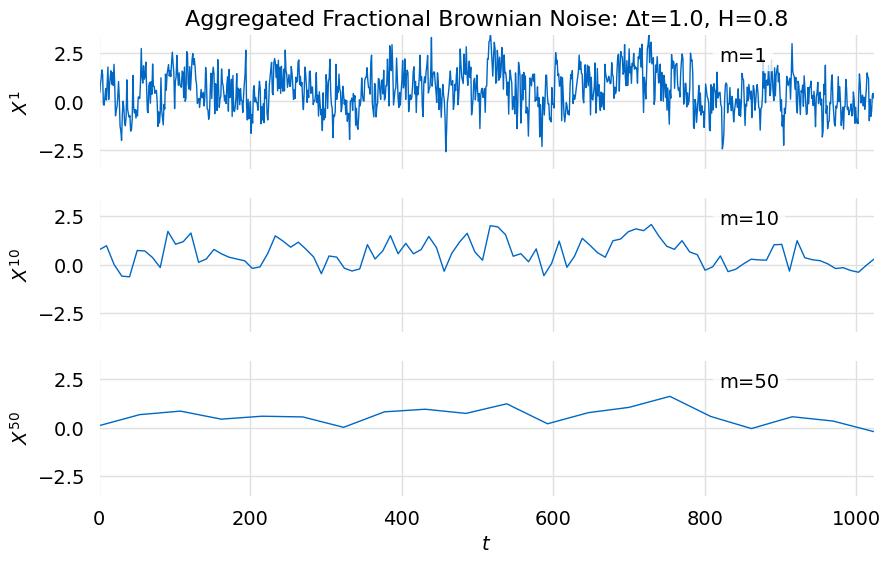

In [4]:
var_agg_comparison(t, fbm_noise, H)

In [5]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [6]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     1331.
Date:                Sat, 30 Sep 2023   Prob (F-statistic):           7.75e-59
Time:                        18:47:10   Log-Likelihood:                 155.15
No. Observations:                 100   AIC:                            -306.3
Df Residuals:                      98   BIC:                            -301.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1132      0.021      5.379      0.000       0.071       0.155
x1            -0.4713      0.013    -36.487      0.000      -0.497      -0.446
==============================================================================
Omnibus:                       24.849   Durbin-Watson:                   0.873
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.677
Skew:                          -1.069   Prob(JB):                     1.47e-09
Kurtosis:                       5.278   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.11324770128358244,
      "err": 0.02105278305763649,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "eefc246a-3c96-495a-94c8-8c918d4b8037",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.47131672004647285,
         "err": 0.012917335480657589,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "eefc246a-3c96-495a-94c8-8c918d4b8037",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9314355392454297,
   "param_transforms": [
      {
         "param": {
            "est": 0.7643416399767635,
            "err": 0.006458667740328794,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "eefc246a-3c96-495

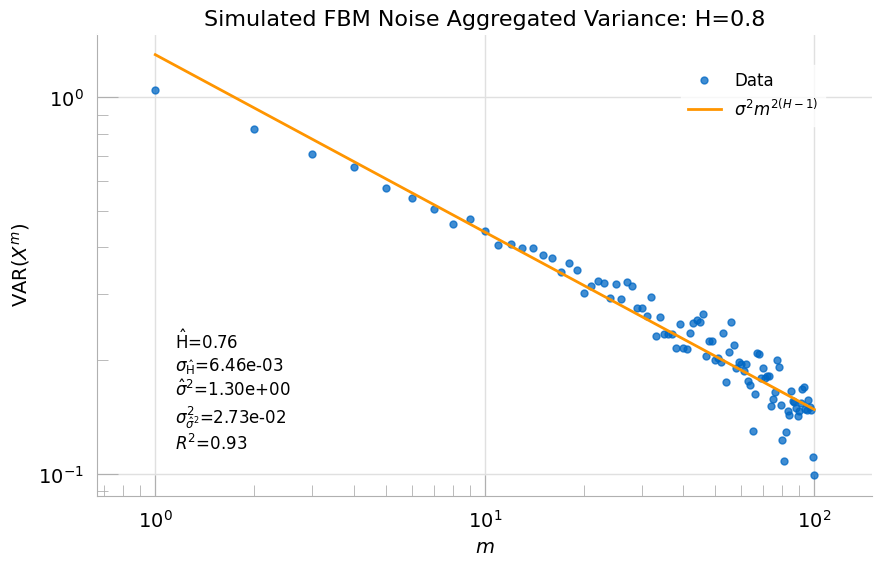

In [8]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.6$

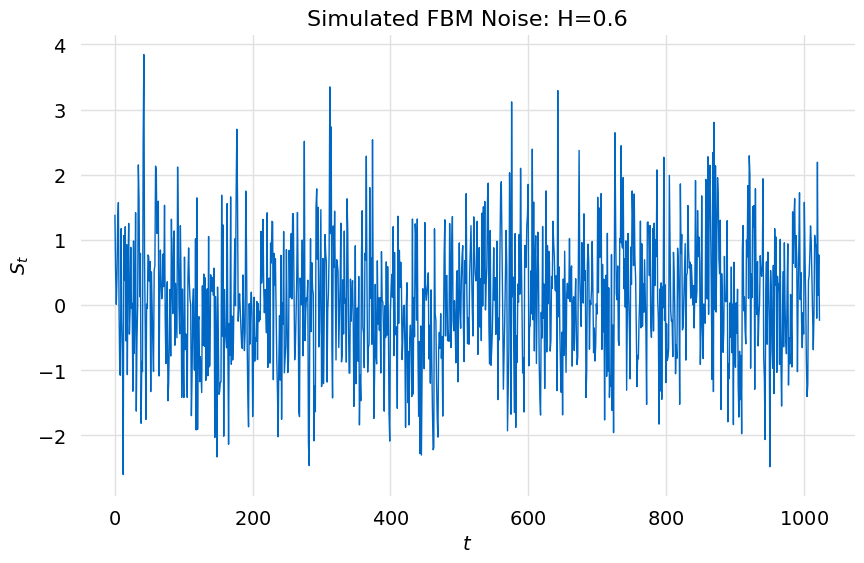

In [9]:
H = 0.6
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

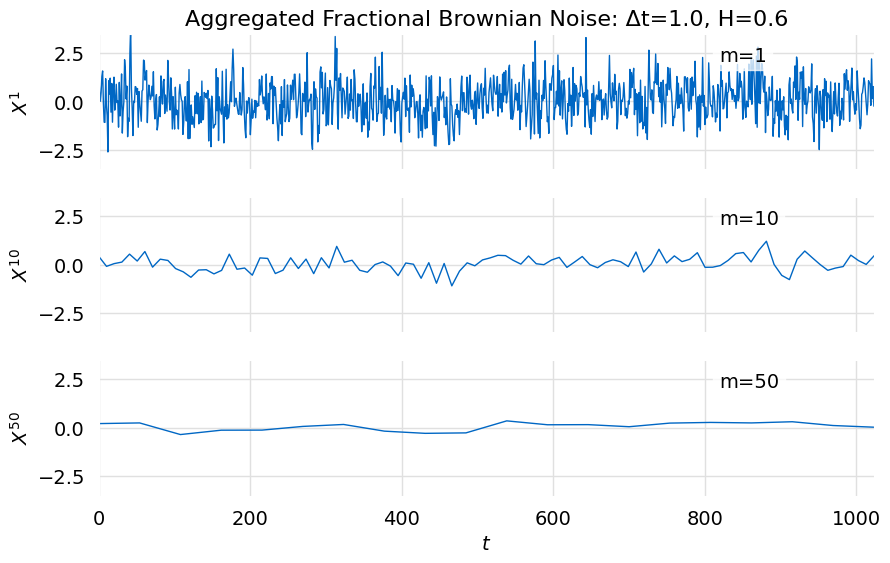

In [10]:
var_agg_comparison(t, fbm_noise, H)

In [11]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [12]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     1510.
Date:                Sat, 30 Sep 2023   Prob (F-statistic):           2.39e-61
Time:                        18:47:10   Log-Likelihood:                 124.59
No. Observations:                 100   AIC:                            -245.2
Df Residuals:                      98   BIC:                            -240.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1222      0.029     -4.277      0.000      -0.179      -0.066
x1            -0.6814      0.018    -38.861      0.000      -0.716      -0.647
==============================================================================
Omnibus:                        1.940   Durbin-Watson:                   0.860
Prob(Omnibus):                  0.379   Jarque-Bera (JB):                1.569
Skew:                           0.304   Prob(JB):                        0.456
Kurtosis:                       3.089   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.12223528802585842,
      "err": 0.028578142606781612,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "a2a15889-a152-404b-86be-57f1c67ff97f",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.6814103560908514,
         "err": 0.017534662968560308,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "a2a15889-a152-404b-86be-57f1c67ff97f",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9390607439877071,
   "param_transforms": [
      {
         "param": {
            "est": 0.6592948219545742,
            "err": 0.008767331484280154,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "a2a15889-a152-40

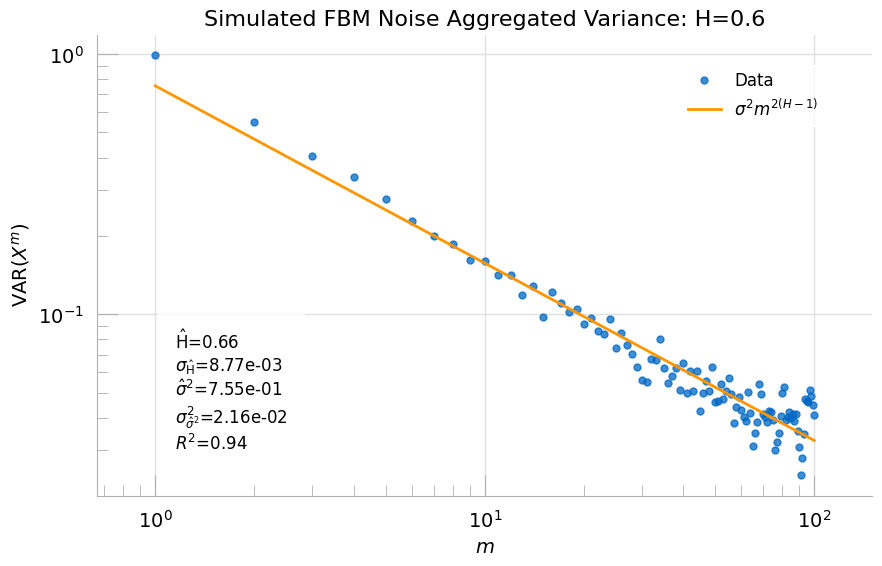

In [14]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.4$

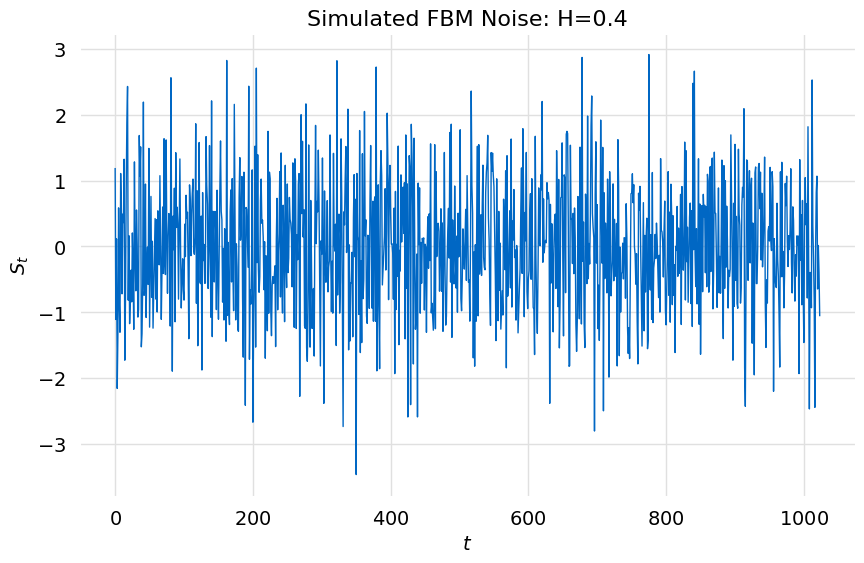

In [15]:
H = 0.4
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

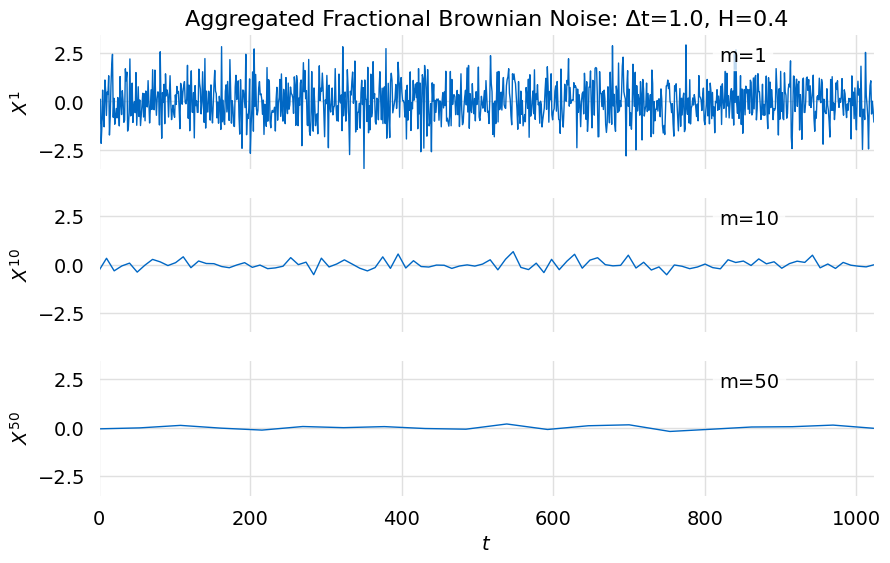

In [16]:
var_agg_comparison(t, fbm_noise, H)

In [17]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [18]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     1733.
Date:                Sat, 30 Sep 2023   Prob (F-statistic):           4.13e-64
Time:                        18:47:11   Log-Likelihood:                 80.681
No. Observations:                 100   AIC:                            -157.4
Df Residuals:                      98   BIC:                            -152.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0840      0.044     -1.895      0.061      -0.172       0.004
x1            -1.1323      0.027    -41.628      0.000      -1.186      -1.078
==============================================================================
Omnibus:                        9.849   Durbin-Watson:                   1.310
Prob(Omnibus):                  0.007   Jarque-Bera (JB):                9.774
Skew:                          -0.693   Prob(JB):                      0.00754
Kurtosis:                       3.652   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.08399667026003312,
      "err": 0.044331978333446785,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "a8c26d92-dc3b-433a-987c-060466f650ab",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.1323152071757332,
         "err": 0.027200728525374585,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "a8c26d92-dc3b-433a-987c-060466f650ab",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9464744238815626,
   "param_transforms": [
      {
         "param": {
            "est": 0.4338423964121334,
            "err": 0.013600364262687292,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "a8c26d92-dc3b-43

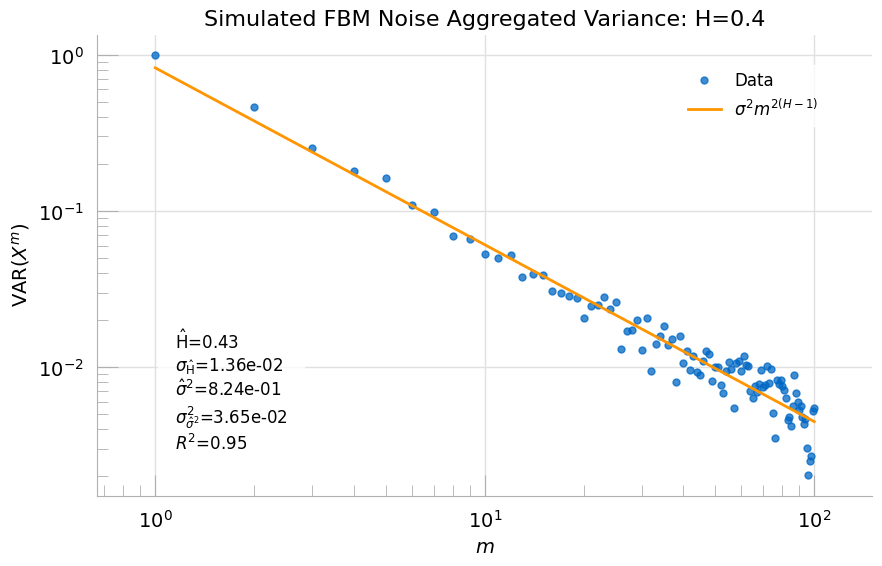

In [20]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.2$

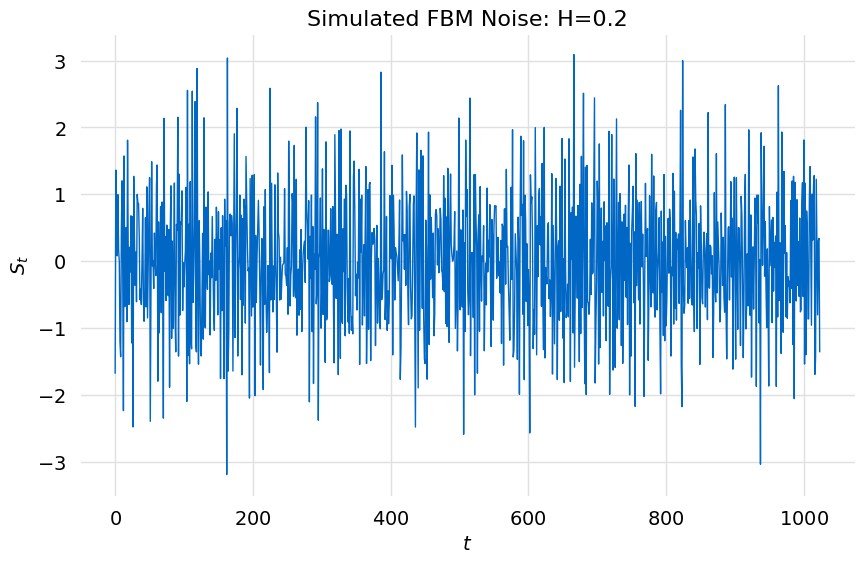

In [21]:
H = 0.2
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

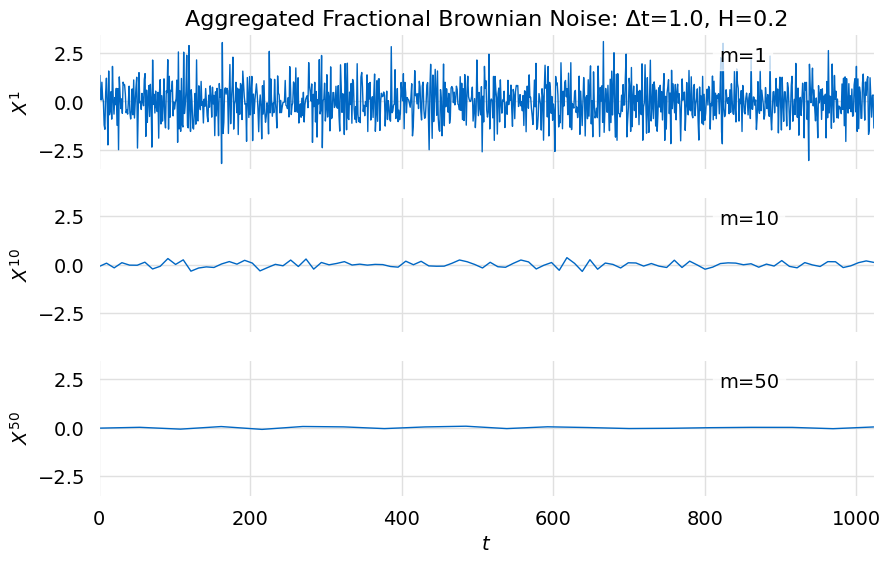

In [22]:
var_agg_comparison(t, fbm_noise, H)

In [23]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [24]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     2425.
Date:                Sat, 30 Sep 2023   Prob (F-statistic):           6.14e-71
Time:                        18:47:12   Log-Likelihood:                 57.671
No. Observations:                 100   AIC:                            -111.3
Df Residuals:                      98   BIC:                            -106.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1292      0.056      2.315      0.023       0.018       0.240
x1            -1.6861      0.034    -49.246      0.000      -1.754      -1.618
==============================================================================
Omnibus:                        3.727   Durbin-Watson:                   1.367
Prob(Omnibus):                  0.155   Jarque-Bera (JB):                3.112
Skew:                          -0.409   Prob(JB):                        0.211
Kurtosis:                       3.276   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.12918489201765931,
      "err": 0.05580220687252021,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "20f6718e-b5f0-4239-a945-a312342452d5",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.6861074149609998,
         "err": 0.0342385054156504,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "20f6718e-b5f0-4239-a945-a312342452d5",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.961159856990334,
   "param_transforms": [
      {
         "param": {
            "est": 0.1569462925195001,
            "err": 0.0171192527078252,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "20f6718e-b5f0-4239-a945

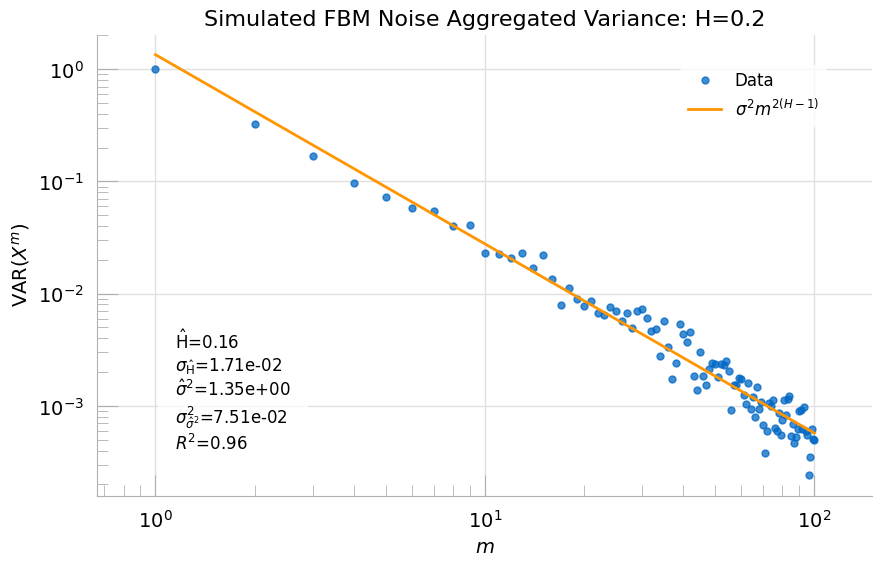

In [26]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")